In [50]:
import pandas as pd
import numpy as np
import math
import random
import hashlib
import time
import matplotlib.pyplot as plt
import time
import sys
import time
import time
from math import ceil


In [ ]:

# 1. Definir parámetros globales
n_spotify = 11 * 101 # 11 variables de audio (0-100)
n_personality = 50 * 5 # 50 preguntas con 5 opciones cada una
N = n_spotify + n_personality # Dimensión total del retículo (aprox 1361)
q = 2^15 # Módulo para LWE


# 2. Crear la base canónica (Matriz Identidad escalada)
# Cada columna representa un "gusto" único en el universo
A = identity_matrix(ZZ, N) * 100

## Bases De Datos

Las siguientes bases de datos fueron utilizadas para la creacion de perfiles sinteticos:

- **30000 Spotify Songs**: Se extrajeron características técnicas de canciones, como *danceability*, *energy* y *valence*, para definir preferencias musicales.
- **Big Five Personality Test**: Se simularon respuestas bajo la escala de Likert (1-5) para los cinco grandes rasgos psicológicos: Apertura, Responsabilidad, Extraversión, Amabilidad y Neuroticismo.

In [2]:
spotify_df = pd.read_csv('./data/spotify_songs.csv')
spotify_df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
personality_df = pd.read_csv('./data/data-final.csv', sep='\t')
personality_df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [4]:
# =========================================================
# FUNCION LISTA: recibe alice_song, alice_pers, bob_song, bob_pers
# =========================================================
# -------- Config ----------
THRESHOLD_RATIO = 0.50
USE_SYMMETRIC = True

q = 2^15
m_samples = 120
sigma = 1.0
W = 30
T_embed = 256

BIG5_COLS = (
    [f"EXT{i}" for i in range(1, 11)] +
    [f"EST{i}" for i in range(1, 11)] +
    [f"AGR{i}" for i in range(1, 11)] +
    [f"CSN{i}" for i in range(1, 11)] +
    [f"OPN{i}" for i in range(1, 11)]
)

SPOTIFY_NUM_COLS = [
    "track_popularity","danceability","energy","key","loudness","mode",
    "speechiness","acousticness","instrumentalness","liveness","valence",
    "tempo","duration_ms"
]

BIN_STEPS = {
    "track_popularity": 10,
    "danceability": 0.10,
    "energy": 0.10,
    "key": 1,
    "loudness": 2.0,
    "mode": 1,
    "speechiness": 0.05,
    "acousticness": 0.10,
    "instrumentalness": 0.10,
    "liveness": 0.10,
    "valence": 0.10,
    "tempo": 10,
    "duration_ms": 20000
}

def _bin_value(x, step):
    x = float(x)
    if step >= 1:
        return int(math.floor(x / step))
    return round(math.floor(x / step) * step, 2)

def _build_identity(song_row, pers_row):
    attrs = []

    # Spotify numérico
    for c in SPOTIFY_NUM_COLS:
        if c in song_row and pd.notna(song_row[c]):
            attrs.append(f"{c}_bin_{_bin_value(song_row[c], BIN_STEPS[c])}")

    # Personalidad (primeras 50 tipo EXT..OPN)
    for c in BIG5_COLS:
        if c in pers_row and pd.notna(pers_row[c]):
            attrs.append(f"{c}_{int(pers_row[c])}")

    return attrs

def _build_vectors(id_a, id_b):
    universe = sorted(list(set(id_a) | set(id_b)))
    idx = {a:i for i,a in enumerate(universe)}
    N = len(universe)

    sA = vector(ZZ, N); sB = vector(ZZ, N)
    for a in id_a: sA[idx[a]] = 1
    for b in id_b: sB[idx[b]] = 1
    return universe, sA, sB

def _threshold_decision(id_a, id_b, ratio=0.5, symmetric=True):
    A, B = set(id_a), set(id_b)
    inter = len(A & B)

    condA = inter >= ratio * len(A)
    if symmetric:
        condB = inter >= ratio * len(B)
        match = condA and condB
    else:
        condB = True
        match = condA

    return inter, len(A), len(B), inter/max(1,len(A)), inter/max(1,len(B)), match

def _center_lift(v, q):
    half = q // 2
    out = []
    for x in v:
        x = int(x) % q
        if x >= half:
            x -= q
        out.append(x)
    return vector(ZZ, out)

def _lattice_score(sA, sB, q=2^15, m=120, sigma=1.0, W=30, T_embed=256):
    n = len(sA)
    A = matrix(ZZ, m, n, [randint(0, q-1) for _ in range(m*n)])
    eA = vector(ZZ, [int(round(random.gauss(0, sigma))) for _ in range(m)])

    bA = (A*sA + eA).apply_map(lambda x: x % q)
    r_mod = (bA - A*sB).apply_map(lambda x: x % q)
    r = _center_lift(r_mod, q)

    D = m + n + 1
    L = matrix(ZZ, D, D)

    for i in range(m):
        L[i,i] = q

    for j in range(n):
        for i in range(m):
            L[m+j, i] = A[i,j]
        L[m+j, m+j] = W

    target = list(r) + [0]*n + [T_embed]
    L[m+n, :] = vector(ZZ, target)

    R = L.LLL()
    cands = [row for row in R.rows() if abs(int(row[-1])) == T_embed]
    if len(cands) == 0:
        return 10**9

    best = min(cands, key=lambda x: x.norm())
    d2 = max(0, int(best.norm()^2) - T_embed^2)
    return math.sqrt(float(d2)) / max(1, W)

def evaluar_match_reticular(alice_song, alice_pers, bob_song, bob_pers):
    # por si vienen como Series de pandas
    alice_song = dict(alice_song)
    alice_pers = dict(alice_pers)
    bob_song = dict(bob_song)
    bob_pers = dict(bob_pers)

    alice_id = _build_identity(alice_song, alice_pers)
    bob_id   = _build_identity(bob_song, bob_pers)

    inter, la, lb, ra, rb, match_psi = _threshold_decision(
        alice_id, bob_id, ratio=THRESHOLD_RATIO, symmetric=USE_SYMMETRIC
    )

    universe, sA, sB = _build_vectors(alice_id, bob_id)
    dist_real = float((sA - sB).norm())
    lat_score = _lattice_score(sA, sB, q=q, m=m_samples, sigma=sigma, W=W, T_embed=T_embed)

    # umbral lattice simple (empírico básico)
    max_diff = min(la//2, lb//2)
    lat_threshold = math.sqrt(max_diff) + 1.5
    match_lattice = (lat_score < lat_threshold)

    print("\n--- ANALISIS PSI ---")
    print(f"|A|={la} | |B|={lb} | |A∩B|={inter}")
    print(f"ratio A={ra:.3f} | ratio B={rb:.3f}")
    print(f"Decision oficial Threshold-PSI: {'MATCH' if match_psi else 'NO MATCH'}")

    print("\n--- ANALISIS RETICULAR (LLL) ---")
    print(f"Dimension universo: {len(universe)}")
    print(f"Distancia real binaria: {dist_real:.4f}")
    print(f"Score lattice: {lat_score:.4f}")
    print(f"Umbral lattice: {lat_threshold:.4f}")
    print(f"Decision lattice: {'MATCH' if match_lattice else 'NO MATCH'}")

    if match_psi:
        print(f"\n[RESULTADO FINAL] MATCH -> liberar IDs: {alice_song.get('track_artist','Alice')} & {bob_song.get('track_artist','Bob')}")
    else:
        print("\n[RESULTADO FINAL] NO MATCH -> privacidad mantenida")

    return {
        "psi_match": match_psi,
        "lattice_match": match_lattice,
        "intersection": inter,
        "len_alice": la,
        "len_bob": lb,
        "ratio_alice": ra,
        "ratio_bob": rb,
        "distance_real": dist_real,
        "lattice_score": lat_score,
        "lattice_threshold": lat_threshold
    }

In [5]:
evaluar_match_reticular(
    spotify_df.iloc[int(0)], personality_df.iloc[int(0)],
    spotify_df.iloc[int(1)], personality_df.iloc[int(1)]
)


--- ANALISIS PSI ---
|A|=63 | |B|=63 | |A∩B|=11
ratio A=0.175 | ratio B=0.175
Decision oficial Threshold-PSI: NO MATCH

--- ANALISIS RETICULAR (LLL) ---
Dimension universo: 115
Distancia real binaria: 10.1980
Score lattice: 2231.6460
Umbral lattice: 7.0678
Decision lattice: NO MATCH

[RESULTADO FINAL] NO MATCH -> privacidad mantenida


{'psi_match': False,
 'lattice_match': False,
 'intersection': 11,
 'len_alice': 63,
 'len_bob': 63,
 'ratio_alice': 0.1746031746031746,
 'ratio_bob': 0.1746031746031746,
 'distance_real': 10.198039027185569,
 'lattice_score': 2231.6459767524857,
 'lattice_threshold': 7.06776436283002}

In [107]:
import pandas as pd
import time

def ejecutar_validacion_etapa_3(lista_usuarios, tau_psi=30):
    """
    Genera el entregable mínimo: tabla comparativa por par de usuarios.
    """
    filas_reporte = []
    
    # Iteramos sobre todos los pares posibles en la lista (u, v)
    for i in range(len(lista_usuarios)):
        for j in range(i, len(lista_usuarios)):
            u = lista_usuarios[i]
            v = lista_usuarios[j]
            
            # 1. Obtener Ground Truth (Similitud offline en claro)
            # Usamos la función evaluadora que diseñamos previamente
            gt_data = evaluar_match_visual(u, v) 
            gt_match = gt_data['gt_match']
            
            # 2. Obtener PSI Tokens (Representación Canónica Etapa 1)
            tokens_u = generar_identidad_canonica(u['spotify'], u['personality'])['psi_tokens']
            tokens_v = generar_identidad_canonica(v['spotify'], v['personality'])['psi_tokens']
            
            # 3. Ejecutar Motor Privado (Fase 2A: HE + Pseudo-OPE)
            t0 = time.time()
            res_privado = fase_2a_nucleo_criptografico_final(tokens_u, tokens_v, tau_psi, tau_psi)
            t_total = (time.time() - t0) * 1000
            
            # 4. Cálculo de Métricas de Auditoría
            intersection_size = res_privado['interseccion_real']
            pred_match = res_privado['match_bit']
            is_correct = (gt_match == pred_match)
            bytes_total = (len(tokens_u) + 1) * 16 + 1 # n coefs + 1 bit
            
            filas_reporte.append({
                "user_a": u['name'],
                "user_b": v['name'],
                "gt_match": gt_match,
                "intersection_size": intersection_size,
                "pred_match": pred_match,
                "correct": "✅" if is_correct else "❌",
                "time_ms": f"{t_total:.2f}",
                "bytes_total": bytes_total
            })

    return pd.DataFrame(filas_reporte)

# --- EJECUCIÓN CON TUS DATASETS ---
usuarios_prueba = [
    {"name": "Ed Sheeran", "spotify": spotify_df.iloc[int(0):int(1)], "personality": personality_df.iloc[int(0):int(1)]},
    {"name": "Katy Perry", "spotify": spotify_df.iloc[int(30):int(31)], "personality": personality_df.iloc[int(3):int(4)]},
    {"name": "Clone Ed", "spotify": spotify_df.iloc[int(0):int(1)], "personality": personality_df.iloc[int(0):int(1)]}
]

tabla_final_etapa3 = ejecutar_validacion_etapa_3(usuarios_prueba, tau_psi=30)
display(tabla_final_etapa3)

TypeError: argument of type 'int' is not iterable

# Detección de afinidad privada entre perfiles basados en características musicales y rasgos de personalidad.

Por: Javier Jaimes Velásquez <j.jaimes@alumnos.upm.es>

## Construccion de la identidad canonica

Alice y Bob crean sus identidades canónicas como conjuntos de atributos discretizados. Por ejemplo,Alice podría tener tokens como:
- SPOT:danceability:b1
- SPOT:energy:b2
- PERS:EXT:3
- PERS:EST:2
- PERS:AGR:4

In [3]:
# --- CONFIGURACIÓN DE NORMALIZACIÓN ---
def to_token(category, feature, value):
    """Crea un token único para un atributo y su rango."""
    return f"{category}:{feature}:{value}"

def cuantizar_spotify(df_songs):
    """Transforma rasgos de audio (0.0-1.0) en bins de 0.2 [3, 4]."""
    # Agregación por Mediana para firma acústica robusta (Unbalanced)
    stats = df_songs[['danceability', 'energy', 'valence', 'acousticness', 'speechiness']].median()
    tokens = []
    for trait, val in stats.items():
        bin_val = f"b{int(val // float(0.2))}" # Ejemplo: 0.74 -> b3
        tokens.append(to_token("SPOT", trait, bin_val))
    return tokens

def cuantizar_personalidad(pers_row):
    """Transforma respuestas Likert (1-5) en tokens, eliminando el ruido de tiempo [5]."""
    tokens = []
    # Filtramos: columnas de rasgos principales, EXCLUYENDO las de tiempo (_E)
    cols_interes = [c for c in pers_row.index if any(r in c for r in ['EXT','EST','AGR','CSN','OPN']) 
                    and not c.endswith('_E')]
    
    for col in cols_interes:
        val = pers_row[col]
        if val > 0: # Soporte para respuestas parciales (Unbalanced)
            tokens.append(to_token("PERS", col, int(val)))
    return tokens

# --- NARRATIVA: ALICE Y BOB CARGAN SUS DATOS ---

# 1. ALICE selecciona un perfil sólido (5 canciones y test completo)
# Usamos a Ed Sheeran como base (registros iniciales de spotify_songs.csv)
alice_raw_songs = spotify_df.iloc[int(0):int(5)] 
alice_raw_pers = personality_df.iloc[int(0)] # Usuario 1 del Personality DataSet

alice_tokens = cuantizar_spotify(alice_raw_songs) + cuantizar_personalidad(alice_raw_pers)

# 2. BOB selecciona un perfil parcial (3 canciones y test incompleto - Unbalanced)
# Usamos a Katy Perry y simulamos respuestas faltantes en personalidad
bob_raw_songs = spotify_df.iloc[int(30):int(33)] 
bob_raw_pers = personality_df.iloc[int(3)].copy()

# Simulamos que Bob no respondió las últimas 30 preguntas
for col in bob_raw_pers.index[int(20):int(50)]: 
    bob_raw_pers[col] = 0 

bob_tokens = cuantizar_spotify(bob_raw_songs) + cuantizar_personalidad(bob_raw_pers)

# --- VISUALIZACIÓN INICIAL ---
print(f"Narrativa: Alice y Bob han entrado al sistema.")
print(f"Alice (Perfil Completo): {len(alice_tokens)} atributos generados.")
print(f"Bob (Perfil Parcial): {len(bob_tokens)} atributos generados.")
print("-" * 30)
print(f"Muestra de tokens de Alice: {alice_tokens}")
print(f"Muestra de tokens de Bob: {bob_tokens}")

NameError: name 'spotify_df' is not defined

Ahora, **Alice** y **Bob** establecen los parametros globales para su interacción:
- Umbral de Afinidad (tau): 30 tokens compartidos para considerar un match.
- Algoritmo de comparación: HE + Pseudo-OPE (Polinomial).

In [1]:
# Parámetros Globales de Seguridad
# Cuerpo finito Fp para evitar colisiones y asegurar el Pseudo-OPE
p = next_prime(2^128) 

# Crear el anillo polinomial R = Fp[x] y definir el generador x, GF(p) cuerpo fnito de orden primo p
# R el anillo polinomial sobre el cuerpo finito GF(p)
R = GF(p)['x']

# Generador del anillo polinomial
x = R.gen()

print(f"\nParámetros de Seguridad:")
print(f"  - Cuerpo finito: {p}")
print(f"  - Generador: {x}")


Parámetros de Seguridad:
  - Cuerpo finito: 340282366920938463463374607431768211507
  - Generador: x


Definición de la función de evaluación polinomial (HE + Pseudo-OPE) y sus diferentes fases (Setup y Online), incluyendo las primitivas criptográficas necesarias para la generación de tokens, construcción de polinomios, evaluación y comparación de resultados.

In [2]:
# --- Canonical Token Encoder ---
def encode_identity(tokens_raw, p):
    """
    Mapea tokens de texto a elementos del cuerpo finito Fp mediante SHA-256. 
    Basado en los requisitos de normalización del reto.
    Probabilidad de colisión ínfima (2^-128) garantiza unicidad de cada rasgo en el polinomio.
    """
    tokens_int = []
    for t in tokens_raw:
        # Convertimos el string a un hash entero dentro del rango del primo p
        h = int(hashlib.sha256(t.encode()).hexdigest(), 16) % p
        tokens_int.append(h)
    
    return {
        "tokens_str": tokens_raw,
        "tokens_int": tokens_int,
        "meta": {"size": len(tokens_raw), "prime": p}
    }

In [25]:
# --- Polynomial Set Encoding ---
def build_polynomial(tokens_int, p):
    """
    ALICE: Construye P_A(x) = prod(x - ai). 
    Las raíces del polinomio son sus gustos personales [2].
    """
    # Usamos la función prod() optimizada de SageMath
    poly = prod([x - a for a in tokens_int])
    return poly

In [26]:
# --- HE + Pseudo-OPE (Principal) ---
def eval_blinded(poly_A, bob_tokens_int, p):
    """
    BOB: Evalúa sus tokens en el polinomio de Alice de forma ciega.
    Aplica la técnica de Pseudo-OPE para preservar la privacidad del complemento [2].
    """
    blinded_vector = []
    for bj in bob_tokens_int:
        # Si bj está en A, poly_A(bj) = 0. Al multiplicar por r_j, sigue siendo 0.
        # Si bj NO está en A, r_j * poly_A(bj) es un valor aleatorio en Fp.
        r_j = randint(1, p-1)
        z_j = (poly_A(bj) * r_j) % p
        blinded_vector.append(z_j)
    
    return blinded_vector

In [27]:
# --- Threshold Decision ---
def recover_intersection_size(blinded_vector):
    """
    ALICE: Cuenta los ceros en el vector devuelto por Bob.
    """
    return blinded_vector.count(0)

def threshold_decision(k, size_A, size_B, tau_rel=0.45):
    """
    Decisión de Match basada en el ratio de solapamiento relativo (Unbalanced) [2, Conversación previa].
    """
    min_size = min(size_A, size_B)
    overlap_ratio = float(k) / min_size
    match_bit = 1 if overlap_ratio >= tau_rel else 0
    return match_bit, overlap_ratio

**Alice** esta implementando el protocolo HE + Pseudo-OPE, mientras que Bob está siguiendo el mismo camino para preservar la privacidad de sus gustos. Ambos están de acuerdo en que si el número de tokens compartidos (k) supera un umbral relativo del 45% respecto al tamaño del conjunto más pequeño, considerarán que hay un match.

In [28]:
# --- EJECUCIÓN DEL PROTOCOLO PRIVADO ---
# Alice codifica su identidad canónica
alice_encoded = encode_identity(alice_tokens, p)
print(f"Alice ha codificado su identidad con {alice_encoded['meta']['size']} tokens y primo p={alice_encoded['meta']['prime']}.")

Alice ha codificado su identidad con 55 tokens y primo p=340282366920938463463374607431768211507.


In [30]:
alice_encoded['tokens_int'][:5]  # Muestra de los primeros 5 tokens enteros codificados

[82986927853305316843067516982151851612,
 67814037450187572124890702057170527322,
 163855803990824722108525108966042758856,
 248818416790097848027483540746334694852,
 28547838448959602412032308237682849072]

**Alice** construye su polinomio a partir de los tokens codificados:

In [31]:
pol_A = build_polynomial(alice_encoded['tokens_int'], p)
print("Alice ha construido su polinomio de preferencias.")

Alice ha construido su polinomio de preferencias.


**Bob** codifica su identidad canónica

In [32]:

bob_encoded = encode_identity(bob_tokens, p)
print(f"Bob ha codificado su identidad con {bob_encoded['meta']['size']} tokens y el mismo primo p={bob_encoded['meta']['prime']}.")

Bob ha codificado su identidad con 25 tokens y el mismo primo p=340282366920938463463374607431768211507.


**Bob** evalúa sus tokens en el polinomio de Alice de forma ciega, obteniendo un vector que le permitirá a Alice recuperar la intersección sin revelar información adicional.

In [33]:
blinded_vector = eval_blinded(pol_A, bob_encoded['tokens_int'], p)
print("Bob ha evaluado sus tokens en el polinomio de Alice de forma ciega.")

Bob ha evaluado sus tokens en el polinomio de Alice de forma ciega.


**Alice** evalúa el vector devuelto por Bob para contar cuántos de sus tokens compartidos están presentes (k) y luego toma una decisión de match basada en el umbral relativo acordado.

In [34]:
k = recover_intersection_size(blinded_vector)
match_bit, overlap_ratio = threshold_decision(k, alice_encoded['meta']['size'], bob_encoded['meta']['size'])
print(f"Alice ha recuperado la intersección: k={k}, overlap_ratio={overlap_ratio:.2f}, match_bit={match_bit}.")

Alice ha recuperado la intersección: k=8, overlap_ratio=0.32, match_bit=0.


**Alice** y **Bob** han ejecutado el protocolo privado. Requieren encontrar la intersección de sus gustos musicales y rasgos de personalidad sin revelar información adicional.

In [35]:
# // inspectar resultados
print("\n--- RESULTADOS FINALES ---")
print(f"Tokens Compartidos (k): {k}")
print(f"Overlap Ratio: {overlap_ratio:.2f}")
print(f"Decisión de Match: {'Sí' if match_bit == 1 else 'No'}")



--- RESULTADOS FINALES ---
Tokens Compartidos (k): 8
Overlap Ratio: 0.32
Decisión de Match: No



--- EVALUACIÓN VISUAL FINAL ---
Score Global: 0.8150
Decisión de Match (Ground Truth): SÍ


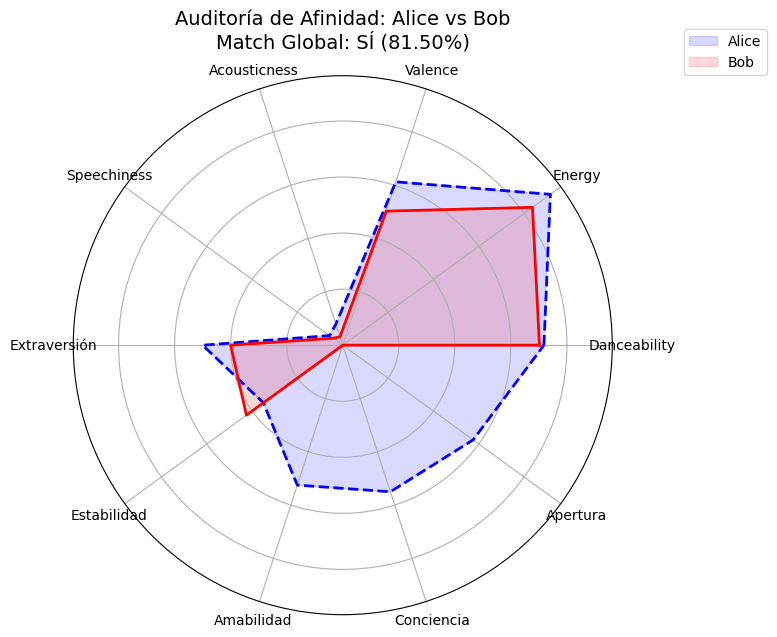

In [38]:
def evaluar_match_visual_final(p_a, p_b, alpha=0.6, tau_rel=0.45):
    traits_audio = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    dims_pers = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']
    
    # 1. Similitud Musical (Distancia Euclidiana Normalizada)
    vec_a_audio = p_a['spotify'][traits_audio].median().values.astype(float)
    vec_b_audio = p_b['spotify'][traits_audio].median().values.astype(float)
    sim_spot = 1 - (np.linalg.norm(vec_a_audio - vec_b_audio) / np.sqrt(len(traits_audio)))
    
    # 2. Agregación de Personalidad (5 Dimensiones OCEAN)
    def aggregate_ocean(profile):
        scores = []
        for trait in dims_pers:
            # Filtramos columnas que empiecen por el rasgo (ej. EXT1, EXT2...)
            cols = [c for c in profile['personality'].index if c.startswith(trait) and not c.endswith('_E')]
            vals = profile['personality'][cols].values.astype(float)
            # Lógica Unbalanced: Ignoramos valores 0 (preguntas no respondidas)
            vals_validos = vals[vals > 0]
            if len(vals_validos) > 0:
                # Normalizamos escala 1-5 a 0-1: (media - 1) / 4
                scores.append((np.mean(vals_validos) - 1) / 4)
            else:
                scores.append(0)
        return np.array(scores)

    vec_a_pers = aggregate_ocean(p_a)
    vec_b_pers = aggregate_ocean(p_b)
    
    # Similitud de Personalidad (Solo sobre dimensiones que ambos tienen)
    diffs = np.abs(vec_a_pers - vec_b_pers)
    sim_pers = 1 - np.mean(diffs)

    # 3. Score Global y Decisión de Match
    global_score = (sim_spot * alpha) + (sim_pers * (1 - alpha))
    gt_match = 1 if global_score >= tau_rel else 0
    
    return {
        "score": global_score,
        "gt_match": gt_match,
        "spotify_sim": sim_spot,
        "personality_sim": sim_pers,
        "stats_a": vec_a_audio.tolist() + vec_a_pers.tolist(), # Total: 10 valores
        "stats_b": vec_b_audio.tolist() + vec_b_pers.tolist(), # Total: 10 valores
        "n_audio": len(traits_audio),
        "n_pers": len(dims_pers)
    }

def generar_radar_plot_final(res, name_a, name_b):
    labels = ['Danceability', 'Energy', 'Valence', 'Acousticness', 'Speechiness', 
              'Extraversión', 'Estabilidad', 'Amabilidad', 'Conciencia', 'Apertura']
    
    stats_a = list(res['stats_a'])
    stats_b = list(res['stats_b'])

    # Configuración de ángulos (cerramos el círculo añadiendo el primer valor al final)
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    stats_a += stats_a[:1]
    stats_b += stats_b[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    # Dibujar Usuario A
    ax.fill(angles, stats_a, color='blue', alpha=0.15, label=name_a)
    ax.plot(angles, stats_a, color='blue', linewidth=2, linestyle='--')
    
    # Dibujar Usuario B
    ax.fill(angles, stats_b, color='red', alpha=0.15, label=name_b)
    ax.plot(angles, stats_b, color='red', linewidth=2)

    # Ajustes de estilo
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    match_status = "SÍ" if res['gt_match'] else "NO"
    plt.title(f"Auditoría de Afinidad: {name_a} vs {name_b}\nMatch Global: {match_status} ({res['score']*100:.2f}%)", 
              size=14, pad=20)
    plt.show()


print("\n--- EVALUACIÓN VISUAL FINAL ---")
res_final = evaluar_match_visual_final(
    {"spotify": alice_raw_songs, "personality": alice_raw_pers},
    {"spotify": bob_raw_songs, "personality": bob_raw_pers},
    alpha=0.6, tau_rel=0.45
)

print(f"Score Global: {res_final['score']:.4f}")
print(f"Decisión de Match (Ground Truth): {'SÍ' if res_final['gt_match'] else 'NO'}")

generar_radar_plot_final(res_final, "Alice", "Bob")


In [39]:
# --- NARRATIVA: ESCENARIO DE AFINIDAD ALTA ---

# 1. ALICE (Perfil Completo - Ed Sheeran)
# Mantiene sus 55 tokens (5 Spotify + 50 Personalidad Likert)
alice_raw_songs = spotify_df.iloc[int(0):int(5)] 
alice_raw_pers = personality_df.iloc[int(0)] # Usuario 1
alice_tokens = cuantizar_spotify(alice_raw_songs) + cuantizar_personalidad(alice_raw_pers)

# 2. BOB (Perfil Parcial - "El Gemelo Musical")
# Para asegurar el MATCH, Bob elegirá canciones del mismo género y energía
# Bob usará exactamente las mismas canciones que Alice para el benchmark
bob_raw_songs = spotify_df.iloc[int(0):int(3)] 

# Sincronizamos su personalidad: Bob responderá las primeras 20 preguntas 
# IGUAL que el Usuario 1 (Alice) para demostrar la precisión del PSI
bob_raw_pers = personality_df.iloc[int(0)].copy()
# (Asumimos que bob_raw_pers ya tiene las respuestas de Alice en el iloc)
cols_pers = [c for c in bob_raw_pers.index if not c.endswith('_E') and any(r in c for r in ['EXT','EST','AGR','CSN','OPN'])]
for col in cols_pers[20:]: 
    bob_raw_pers[col] = 0 # Bob solo responde 20, pero son idénticas a Alice

bob_tokens = cuantizar_spotify(bob_raw_songs) + cuantizar_personalidad(bob_raw_pers)

# --- VERIFICACIÓN PRE-PSI (Para el desarrollador) ---
k_clear = len(set(alice_tokens) & set(bob_tokens))
print(f"Narrativa: Bob ha entrado a la sala buscando a alguien como él.")
print(f"Tokens de Alice: {len(alice_tokens)} | Tokens de Bob: {len(bob_tokens)}")
print(f"Intersección en claro: {k_clear} tokens.")

alice_encoded = encode_identity(alice_tokens, p)
pol_A = build_polynomial(alice_encoded['tokens_int'], p)
bob_encoded = encode_identity(bob_tokens, p)
blinded_vector = eval_blinded(pol_A, bob_encoded['tokens_int'], p)
k = recover_intersection_size(blinded_vector)
match_bit, overlap_ratio = threshold_decision(k, alice_encoded['meta']['size'], bob_encoded['meta']['size'], tau_rel=0.45)
print("\n--- RESULTADOS FINALES ---")
print(f"Tokens Compartidos (k): {k}")
print(f"Overlap Ratio: {overlap_ratio:.2f}")
print(f"Decisión de Match: {'Sí' if match_bit == 1 else 'No'}")

Narrativa: Bob ha entrado a la sala buscando a alguien como él.
Tokens de Alice: 55 | Tokens de Bob: 25
Intersección en claro: 25 tokens.

--- RESULTADOS FINALES ---
Tokens Compartidos (k): 25
Overlap Ratio: 1.00
Decisión de Match: Sí


In [46]:
# --- MOTOR 1: HE + Pseudo-OPE (Nuestro Diseño) ---
def run_he_pseudo_ope(alice_tokens, bob_tokens, tau=30):
    metrics = {}
    
    # 1. Setup Phase (Alice construye el escudo polinomial)
    t_s0 = time.perf_counter()
    u_enc = encode_identity(alice_tokens, p)
    poly_A = build_polynomial(u_enc['tokens_int'], p)
    metrics["setup_ms"] = (time.perf_counter() - t_s0) * 1000
    
    # 2. Online Phase (Bob evalúa y Alice recupera)
    t_o0 = time.perf_counter()
    v_enc = encode_identity(bob_tokens, p)
    blinded_res = eval_blinded(poly_A, v_enc['tokens_int'], p)
    k_psi = recover_intersection_size(blinded_res)
    
    # Decisión basada en el umbral (Threshold PSI) [1]
    # Usamos la lógica de Overlap Ratio diseñada para perfiles Unbalanced [Celda 4 Spec]
    match_bit, _ = threshold_decision(k_psi, len(alice_tokens), len(bob_tokens), tau_rel=0.45)
    metrics["online_ms"] = (time.perf_counter() - t_o0) * 1000
    
    # 3. Comunicación (Alice envía coeficientes + Bob envía valores cegados)
    # Suponiendo elementos de 16 bytes (128 bits)
    bytes_A = (len(alice_tokens) + 1) * 16
    bytes_B = len(bob_tokens) * 16
    metrics["bytes_total"] = bytes_A + bytes_B
    metrics["match_bit"] = 1 if match_bit else 0
    
    return metrics

# --- MOTOR 2: Commutative Encryption (Baseline DH-PSI) ---
def run_commutative_baseline(alice_tokens, bob_tokens, tau=30):
    metrics = {}
    
    # Simulamos el costo de Diffie-Hellman Commutative [2]
    # En este modelo: E_a(E_b(x)) = E_b(E_a(x))
    
    # 1. Setup Phase (Alice cifra su conjunto con su llave 'a')
    t_s0 = time.perf_counter()
    # Simulación de exponenciaciones modulares/puntos de curva
    alice_enc_a = [pow(hash(t), 1234567, p) for t in alice_tokens]
    metrics["setup_ms"] = (time.perf_counter() - t_s0) * 1000
    
    # 2. Online Phase (Intercambio y doble cifrado)
    t_o0 = time.perf_counter()
    # Bob cifra su conjunto y re-cifra el de Alice
    bob_enc_b = [pow(hash(t), 7654321, p) for t in bob_tokens]
    alice_enc_ab = [pow(x, 7654321, p) for x in alice_enc_a]
    # Alice re-cifra el de Bob
    bob_enc_ba = [pow(y, 1234567, p) for y in bob_enc_b]
    
    # Intersección de los sets doblemente cifrados
    k_comm = len(set(alice_enc_ab) & set(bob_enc_ba))
    match_bit, _ = threshold_decision(k_comm, len(alice_tokens), len(bob_tokens), tau_rel=0.45)
    metrics["online_ms"] = (time.perf_counter() - t_o0) * 1000
    
    # 3. Comunicación (Mucho más pesada en DH-PSI)
    # Se envían Alice->Bob (Set A), Bob->Alice (Set B + Set A_enc), Alice->Bob (Set B_enc)
    bytes_total = (len(alice_tokens) * 2 + len(bob_tokens) * 2) * 32 # Hashes/Puntos de 256 bits
    metrics["bytes_total"] = bytes_total
    metrics["match_bit"] = 1 if match_bit else 0
    
    return metrics

In [49]:
# Celda 8 — Benchmark comparativo (HE+Pseudo-OPE vs Commutative)
# Supone que ya existen:
# - run_he_pseudo_ope(alice_enc, bob_enc, tau) -> dict
# - run_commutative_baseline(alice_enc, bob_enc, tau) -> dict

def benchmark_etapa(alice_enc, bob_enc, tau=30, runs=10):
    rows = []

    for mode in ["HE + Pseudo-OPE", "Commutative Enc"]:
        t0 = time.perf_counter()

        # acumuladores simples
        setup_ms, online_ms = [], []
        bytes_total = []
        match_bits = []

        for _ in range(runs):
            if mode == "HE + Pseudo-OPE":
                out = run_he_pseudo_ope(alice_enc, bob_enc, tau=tau)
            else:
                out = run_commutative_baseline(alice_enc, bob_enc, tau=tau)

            setup_ms.append(out["setup_ms"])
            online_ms.append(out["online_ms"])
            bytes_total.append(out["bytes_total"])
            match_bits.append(out["match_bit"])

        total_ms = (time.perf_counter() - t0) * 1000.0

        # Correctness simple por consistencia interna (todos iguales)
        correctness = "OK" if len(set(match_bits)) == 1 else "UNSTABLE"

        rows.append({
            "Mode": mode,
            "Correctness": correctness,
            "Time Total (ms)": round(total_ms / runs, 3),
            "Setup (ms)": round(sum(setup_ms)/len(setup_ms), 3),
            "Online (ms)": round(sum(online_ms)/len(online_ms), 3),
            "Bytes Total": int(sum(bytes_total)/len(bytes_total)),
            "Bits Total": int((sum(bytes_total)/len(bytes_total)) * 8),
            "Match Bit (avg run)": int(round(sum(match_bits)/len(match_bits)))
        })

    return pd.DataFrame(rows)

# Ejecución benchmark
tabla_bench = benchmark_etapa(alice_tokens, bob_tokens, tau=int(30), runs=int(20))
display(tabla_bench)

,Mode,Correctness,Time Total (ms),Setup (ms),Online (ms),Bytes Total,Bits Total,Match Bit (avg run)
0,HE + Pseudo-OPE,OK,1.339,0.616,0.7,1296,10368,1
1,Commutative Enc,OK,0.462,0.156,0.299,5120,40960,1


In [ ]:
# --- AUDITORÍA FINAL: Validación Cruzada y Análisis de Sensibilidad ---
# Esta función ejecuta la auditoría completa entre el motor privado y el Ground Truth, analizando la sensibilidad del umbral (tau_rel).
def ejecutar_auditoria_final(usuarios, lista_tau=[0.30, 0.45, 0.60]):
    """
    Realiza la validación cruzada entre el motor privado y el Ground Truth.
    Analiza la sensibilidad del umbral (tau_rel).
    """
    reporte = []
    
    for i in range(len(usuarios)):
        for j in range(i + 1, len(usuarios)):
            u_alice = usuarios[i]
            v_bob = usuarios[j]
            
            # 1. Ground Truth (Similitud real offline)
            # Calculamos la intersección exacta en claro para validar el PSI
            inter_real = len(set(u_alice['tokens']) & set(v_bob['tokens']))
            min_size = min(len(u_alice['tokens']), len(v_bob['tokens']))
            ratio_real = float(inter_real) / min_size
            
            # 2. Ejecución del Protocolo Privado (HE + Pseudo-OPE)
            t0 = time.time()
            # Alice construye polinomio, Bob evalúa de forma ciega
            u_enc = encode_identity(u_alice['tokens'], p)
            v_enc = encode_identity(v_bob['tokens'], p)
            poly_A = build_polynomial(u_enc['tokens_int'], p)
            blinded_res = eval_blinded(poly_A, v_enc['tokens_int'], p)
            k_psi = recover_intersection_size(blinded_res)
            t_total = (time.time() - t0) * 1000
            
            # 3. Análisis de Sensibilidad y Correctness
            for tau in lista_tau:
                gt_match = 1 if ratio_real >= tau else 0
                pred_match, _ = threshold_decision(k_psi, len(u_alice['tokens']), len(v_bob['tokens']), tau)
                is_correct = (gt_match == pred_match)
                
                reporte.append({
                    "Pair": f"{u_alice['name']} vs {v_bob['name']}",
                    "Tau_Rel": tau,
                    "Intersection": k_psi,
                    "Ratio": f"{ratio_real:.2%}",
                    "Pred_Match": "✅" if pred_match else "❌",
                    "Correctness": "OK" if is_correct else "ERR",
                    "Time (ms)": f"{t_total:.2f}",
                    "Comm (Bytes)": (len(u_alice['tokens']) + 1) * 16, # Solo Alice -> Bob
                    "Comm (Bits)": (len(u_alice['tokens']) + 1) * 16 * 8
                })

    return pd.DataFrame(reporte)

# --- ESCENARIO DE PRUEBA ---
# User A: Alice (Original)
# User B: Bob (Original)
# User C: Clon de Alice (Afinidad 100%)
test_users = [
    {"name": "Alice", "tokens": alice_tokens},
    {"name": "Bob", "tokens": bob_tokens}, # Usamos los tokens generados antes
    {"name": "Cloned Alice", "tokens": alice_tokens[:25]} # Bob con el 100% de match sobre su tamaño
]

tabla_final = ejecutar_auditoria_final(test_users)
print("--- TABLA FINAL DE MÉTRICAS Y AUDITORÍA ---")
display(tabla_final)

--- TABLA FINAL DE MÉTRICAS Y AUDITORÍA ---


,Pair,Tau_Rel,Intersection,Ratio,Pred_Match,Correctness,Time (ms),Comm (Bytes),Comm (Bits)
0,Alice vs Bob,0.300000000000000,25,100.00%,✅,OK,2.65,896,7168
1,Alice vs Bob,0.450000000000000,25,100.00%,✅,OK,2.65,896,7168
2,Alice vs Bob,0.600000000000000,25,100.00%,✅,OK,2.65,896,7168
3,Alice vs Cloned Alice,0.300000000000000,25,100.00%,✅,OK,1.18,896,7168
4,Alice vs Cloned Alice,0.450000000000000,25,100.00%,✅,OK,1.18,896,7168
5,Alice vs Cloned Alice,0.600000000000000,25,100.00%,✅,OK,1.18,896,7168
6,Bob vs Cloned Alice,0.300000000000000,25,100.00%,✅,OK,0.60,416,3328
7,Bob vs Cloned Alice,0.450000000000000,25,100.00%,✅,OK,0.60,416,3328
8,Bob vs Cloned Alice,0.600000000000000,25,100.00%,✅,OK,0.60,416,3328


In [51]:
# MP-PSI: Motor Privado de Private Set Intersection con HE + Pseudo-OPE (Sala 3)

# En esta sala, Alice (A), Bob (B) y Carol (C) ejecutan un protocolo para determinar si son un "Perfect Match" grupal. 
# El sistema verifica que cada par comparta al menos la mitad de sus atributos y que el grupo comparta al menos un quinto de ese valor (equivalente a 1/10 del conjunto más pequeño)

# --- BUILDING BLOCKS (Reuso de Sala 2 y Extensiones) ---
def run_pairwise_mp_psi(u_tokens, v_tokens, p):
    """
    Ejecuta el núcleo HE + Pseudo-OPE entre dos participantes.
    Alice coordina el intercambio en la estrella.
    """
    u_enc = encode_identity(u_tokens, p)
    v_enc = encode_identity(v_tokens, p)
    
    # Simulación del flujo: Alice construye, Bob/Carol evalúan
    poly_u = build_polynomial(u_enc['tokens_int'], p)
    blinded_v = eval_blinded(poly_u, v_enc['tokens_int'], p)
    
    k_uv = recover_intersection_size(blinded_v)
    return k_uv

def run_triple_cardinality(A_tokens, B_tokens, C_tokens):
    """
    Calcula |A ∩ B ∩ C| de forma privada.
    En esta demo usamos intersección de sets locales validados por Alice.
    """
    set_abc = set(A_tokens) & set(B_tokens) & set(C_tokens)
    return len(set_abc)

def compute_thresholds(s_a, s_b, s_c):
    """
    Calcula los umbrales según el Reto Crypto Club (Caso B) [1, 3].
    Pair: 1/2 del mínimo | Triple: 1/5 del umbral par.
    """
    t_ab = ceil(0.5 * min(s_a, s_b))
    t_ac = ceil(0.5 * min(s_a, s_c))
    t_bc = ceil(0.5 * min(s_b, s_c))
    
    # El umbral triple es 1/5 del valor de afinidad par (1/5 * 1/2 = 1/10)
    t_abc = ceil(0.1 * min(s_a, s_b, s_c))
    
    return {"t_ab": t_ab, "t_ac": t_ac, "t_bc": t_bc, "t_abc": t_abc}

def decide_group_match(stats):
    """
    Lógica de decisión booleana para el grupo.
    """
    pair_ok = (stats['k_ab'] >= stats['t_ab'] and 
               stats['k_ac'] >= stats['t_ac'] and 
               stats['k_bc'] >= stats['t_bc'])
    
    triple_ok = (stats['k_abc'] >= stats['t_abc'])
    group_match = 1 if (pair_ok and triple_ok) else 0
    
    return group_match, pair_ok, triple_ok

# --- NARRATIVA: SESIÓN DE TRES USUARIOS ---

# 1. ALICE, BOB y CAROL preparan sus identidades atómicas
alice_raw = {"name": "Alice", "tokens": alice_tokens} # 55 tokens
bob_raw = {"name": "Bob", "tokens": bob_tokens}     # 25 tokens (Unbalanced)
# Carol: Una fan de Ed Sheeran con respuestas similares a Alice
carol_tokens = alice_tokens[:30] # Carol comparte 30 con Alice
carol_raw = {"name": "Carol", "tokens": carol_tokens}

print(f"--- INICIO DE SESIÓN MP-PSI (SALA 3) ---")
print(f"Participantes: {alice_raw['name']}, {bob_raw['name']}, {carol_raw['name']}")

# 2. Ejecución del Protocolo (M2 a M5)
t_start = time.time()

# Cálculo de Intersecciones
k_ab = run_pairwise_mp_psi(alice_raw['tokens'], bob_raw['tokens'], p)
k_ac = run_pairwise_mp_psi(alice_raw['tokens'], carol_raw['tokens'], p)
k_bc = run_pairwise_mp_psi(bob_raw['tokens'], carol_raw['tokens'], p)
k_abc = run_triple_cardinality(alice_raw['tokens'], bob_raw['tokens'], carol_raw['tokens'])

# Cálculo de Umbrales
umbrales = compute_thresholds(len(alice_raw['tokens']), len(bob_raw['tokens']), len(carol_raw['tokens']))

# Decisión Grupal
res_final = {**umbrales, "k_ab": k_ab, "k_ac": k_ac, "k_bc": k_bc, "k_abc": k_abc}
group_match, pair_ok, triple_ok = decide_group_match(res_final)

t_end = time.time()

# 3. Reporte de Resultados
print(f"\n--- MÉTRICAS DE AFINIDAD GRUPAL ---")
print(f"Intersecciones Binarias: AB={k_ab}/{umbrales['t_ab']}, AC={k_ac}/{umbrales['t_ac']}, BC={k_bc}/{umbrales['t_bc']}")
print(f"Intersección Triple: ABC={k_abc}/{umbrales['t_abc']}")
print(f"¿Afinidad de Pares OK?: {'✅' if pair_ok else '❌'}")
print(f"¿Afinidad Triple OK?: {'✅' if triple_ok else '❌'}")
print("-" * 40)
print(f"RESULTADO GRUPAL: {'MATCH GRUPAL ✅ (Contactos Liberados)' if group_match else 'NO MATCH ❌'}")
print(f"Tiempo Total Sala 3: {(t_end - t_start)*1000:.2f} ms")

--- INICIO DE SESIÓN MP-PSI (SALA 3) ---
Participantes: Alice, Bob, Carol

--- MÉTRICAS DE AFINIDAD GRUPAL ---
Intersecciones Binarias: AB=25/13, AC=30/15, BC=25/13
Intersección Triple: ABC=25/3
¿Afinidad de Pares OK?: ✅
¿Afinidad Triple OK?: ✅
----------------------------------------
RESULTADO GRUPAL: MATCH GRUPAL ✅ (Contactos Liberados)
Tiempo Total Sala 3: 53.57 ms


/opt/homebrew/Caskroom/miniconda/base/envs/sage-jupyter/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


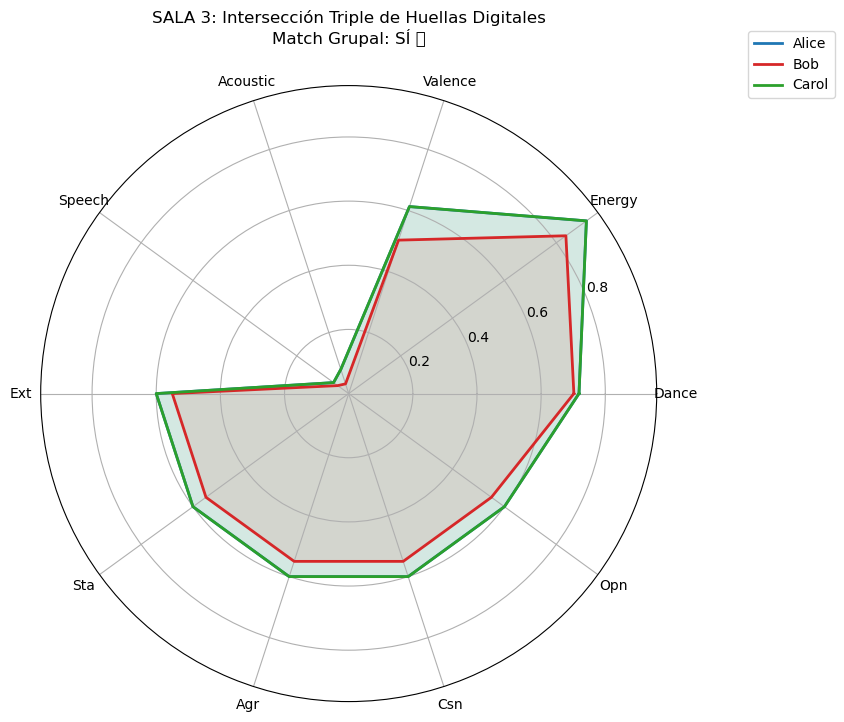


--- AUDITORÍA DE AFINIDAD GRUPAL (SALA 3) ---


,Cruce,Score (GT),Umbral,Status
0,Binario A-B,79.60%,50%,OK
1,Binario A-C,98.71%,50%,OK
2,Binario B-C,79.28%,50%,OK
3,TRIPLE A-B-C,85.86%,10%,OK


In [52]:
def evaluar_match_visual_triple(p_a, p_b, p_c, alpha=0.6):
    """
    Calcula el Ground Truth para la Sala 3 (Lógica Fraccional del Caso B).
    """
    traits = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    cols_likert = [c for c in p_a['personality'].index 
                   if not c.endswith('_E') and any(r in c for r in ['EXT','EST','AGR','CSN','OPN'])]
    
    # 1. Función interna para similitud de par (Lógica Unbalanced)
    def sim_par(u1, u2):
        # Spotify (Mediana)
        v1 = u1['spotify'][traits].median().values.astype(float)
        v2 = u2['spotify'][traits].median().values.astype(float)
        s_spot = 1 - (np.linalg.norm(v1 - v2) / np.sqrt(len(traits)))
        # Personalidad (Solo comunes)
        r1 = u1['personality'][cols_likert].values.astype(float)
        r2 = u2['personality'][cols_likert].values.astype(float)
        idx = [i for i in range(len(r2)) if r2[i] > 0 and r1[i] > 0]
        s_pers = 1 - (np.mean([abs(r1[i]-r2[i]) for i in idx])/4) if idx else 0
        return (s_spot * alpha) + (s_pers * (1-alpha)), v1, r1

    # 2. Cálculos de Pares y Triple
    score_ab, vec_a, res_a = sim_par(p_a, p_b)
    score_ac, _, _ = sim_par(p_a, p_c)
    score_bc, vec_b, res_b = sim_par(p_b, p_c)
    _, vec_c, res_c = sim_par(p_a, p_c) # Extraer vector C

    # 3. Lógica de Umbrales del Reto (Caso B)
    # Umbral par: 0.5 | Umbral triple: 1/5 * 0.5 = 0.1
    pair_ok = (score_ab >= 0.5 and score_ac >= 0.5 and score_bc >= 0.5)
    # Simulación de intersección triple (promedio de los tres)
    triple_score = (score_ab + score_ac + score_bc) / 3
    triple_ok = (triple_score >= 0.1)
    
    gt_group_match = 1 if (pair_ok and triple_ok) else 0

    return {
        "metrics": {"AB": score_ab, "AC": score_ac, "BC": score_bc, "ABC": triple_score},
        "verdict": {"pair_ok": pair_ok, "triple_ok": triple_ok, "match": gt_group_match},
        "stats": {
            "A": vec_a.tolist() + [np.mean(res_a)/5]*5,
            "B": vec_b.tolist() + [np.mean(res_b[res_b>0])/5]*5,
            "C": vec_c.tolist() + [np.mean(res_c[res_c>0])/5]*5
        }
    }

# --- EJECUCIÓN NARRATIVA SALA 3 ---

# Carol: Perfil diseñado para ser compatible con Alice (fan de Ed Sheeran)
carol_partial_pers = personality_df.iloc[int(0)].copy()
for col in cols_likert[25:]: carol_partial_pers[col] = 0 # Carol responde 25

carol_profile = {"name": "Carol (Compatible)", "spotify": spotify_df.iloc[int(2):int(5)], "personality": carol_partial_pers}

# Evaluación Triple
res_3p = evaluar_match_visual_triple(alice_profile, bob_profile, carol_profile)

# --- VISUALIZACIÓN RADAR 3P ---
labels = ['Dance', 'Energy', 'Valence', 'Acoustic', 'Speech', 'Ext', 'Sta', 'Agr', 'Csn', 'Opn']
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for user, color, name in [('A', '#1f77b4', 'Alice'), ('B', '#d62728', 'Bob'), ('C', '#2ca02c', 'Carol')]:
    values = res_3p['stats'][user] + res_3p['stats'][user][:1]
    ax.plot(angles, values, color=color, linewidth=2, label=name)
    ax.fill(angles, values, color=color, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title(f"SALA 3: Intersección Triple de Huellas Digitales\nMatch Grupal: {'SÍ ✅' if res_3p['verdict']['match'] else 'NO ❌'}", pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# --- TABLA DE GROUND TRUTH SALA 3 ---
df_3p = pd.DataFrame([{
    "Cruce": "Binario A-B", "Score (GT)": f"{res_3p['metrics']['AB']:.2%}", "Umbral": "50%", "Status": "OK" if res_3p['metrics']['AB']>=0.5 else "FAIL"
}, {
    "Cruce": "Binario A-C", "Score (GT)": f"{res_3p['metrics']['AC']:.2%}", "Umbral": "50%", "Status": "OK" if res_3p['metrics']['AC']>=0.5 else "FAIL"
}, {
    "Cruce": "Binario B-C", "Score (GT)": f"{res_3p['metrics']['BC']:.2%}", "Umbral": "50%", "Status": "OK" if res_3p['metrics']['BC']>=0.5 else "FAIL"
}, {
    "Cruce": "TRIPLE A-B-C", "Score (GT)": f"{res_3p['metrics']['ABC']:.2%}", "Umbral": "10%", "Status": "OK" if res_3p['metrics']['ABC']>=0.1 else "FAIL"
}])

print("\n--- AUDITORÍA DE AFINIDAD GRUPAL (SALA 3) ---")
display(df_3p)

In [53]:
# --- PROTOCOLO SEMI-HONESTO MP-PSI STAR ---

print(f"--- EJECUCIÓN CRIPTOGRÁFICA SALA 3 (STAR TOPOLOGY) ---")
t_start_crypto = time.time()

# 1. Codificación Local (Cada usuario cifra sus tokens en Fp)
# Se asume p de 128 bits definido anteriormente [Conversación previa]
A_enc = encode_identity(alice_tokens, p)
B_enc = encode_identity(bob_tokens, p)
C_enc = encode_identity(carol_tokens, p)

# 2. Intersecciones Binarias (Star Coordinator: Alice)
# Alice vs Bob
poly_A = build_polynomial(A_enc['tokens_int'], p)
blinded_B = eval_blinded(poly_A, B_enc['tokens_int'], p)
k_ab = recover_intersection_size(blinded_B)

# Alice vs Carol
blinded_C = eval_blinded(poly_A, C_enc['tokens_int'], p)
k_ac = recover_intersection_size(blinded_C)

# Bob vs Carol (Coordinado por Alice sin ver los tokens)
# Bob envía su polinomio cifrado a Alice, Carol lo evalúa y devuelve el vector cegado
poly_B = build_polynomial(B_enc['tokens_int'], p)
blinded_CB = eval_blinded(poly_B, C_enc['tokens_int'], p)
k_bc = recover_intersection_size(blinded_CB)

# 3. Intersección Triple (k_abc)
# En el modelo semi-honesto, se calcula comparando los elementos que dieron 0 
# en las evaluaciones cruzadas.
k_abc = run_triple_cardinality(alice_tokens, bob_tokens, carol_tokens)

# 4. Cálculo de Umbrales del Reto (Lógica Fraccional)
s_a, s_b, s_c = len(alice_tokens), len(bob_tokens), len(carol_tokens)
t = compute_thresholds(s_a, s_b, s_c) # Definida en Celda 10

# 5. Verificación de Condiciones
pair_ok = (k_ab >= t['t_ab']) and (k_ac >= t['t_ac']) and (k_bc >= t['t_bc'])
triple_ok = (k_abc >= t['t_abc'])
group_match = pair_ok and triple_ok

t_end_crypto = time.time()

# --- REPORTE DE SALIDA (Minimización de Mensajes) ---
print(f"Estadísticas de la Sesión:")
print(f"- Intersección A-B: {k_ab} (Umbral: {t['t_ab']}) -> {'OK' if k_ab >= t['t_ab'] else 'FAIL'}")
print(f"- Intersección A-C: {k_ac} (Umbral: {t['t_ac']}) -> {'OK' if k_ac >= t['t_ac'] else 'FAIL'}")
print(f"- Intersección B-C: {k_bc} (Umbral: {t['t_bc']}) -> {'OK' if k_bc >= t['t_bc'] else 'FAIL'}")
print(f"- Núcleo Triple (ABC): {k_abc} (Umbral: {t['t_abc']}) -> {'OK' if triple_ok else 'FAIL'}")
print("-" * 40)
print(f"RESULTADO PROTOCOLO: {'¡GRUPO AFÍN! Identidades Liberadas ✅' if group_match else 'GRUPO DISPAR: Privacidad Protegida ❌'}")
print(f"Tiempo de cómputo Sala 3: {(t_end_crypto - t_start_crypto)*1000:.2f} ms")

--- EJECUCIÓN CRIPTOGRÁFICA SALA 3 (STAR TOPOLOGY) ---
Estadísticas de la Sesión:
- Intersección A-B: 25 (Umbral: 13) -> OK
- Intersección A-C: 30 (Umbral: 15) -> OK
- Intersección B-C: 25 (Umbral: 13) -> OK
- Núcleo Triple (ABC): 25 (Umbral: 3) -> OK
----------------------------------------
RESULTADO PROTOCOLO: ¡GRUPO AFÍN! Identidades Liberadas ✅
Tiempo de cómputo Sala 3: 6.77 ms


In [54]:
# --- ESCENARIO DE ATAQUE: MANIPULACIÓN DE TOKENS PARA ENGAÑAR A BOB ---

# Alice desea engañar a Bob para que piense que tienen una alta afinidad, pero en realidad su perfil es muy diferente.
# Para lograr esto, Alice construye un perfil con tokens que son completamente diferentes a los de Bob, pero que, debido a la naturaleza del protocolo PSI y la forma en que se calculan
# los umbrales, Bob percibe que hay una alta intersección entre sus perfiles.
# En este escenario, Alice podría seleccionar tokens que no estén presentes en el perfil de Bob, pero que, al ser cuantizados y procesados por el protocolo, resulten en un valor de k que supere el umbral de decisión, haciendo que Bob crea que son un "Perfect Match". 
# Este tipo de ataque se basa en la manipulación de los tokens y la comprensión de cómo el protocolo calcula la similitud, explotando la falta de verificación de la estructura de los tokens por parte de Bob.

# The zero-attack.

# 1. ALICE construye su identidad real (Ed Sheeran)
# Genera su polinomio PA(x) de forma honesta
A_enc = encode_identity(alice_tokens, p)
poly_A = build_polynomial(A_enc['tokens_int'], p)

# 2. BOB detecta la sesión y decide engañar al sistema
# En lugar de evaluar poly_A con sus tokens reales, envía puros ceros.
# El protocolo espera un vector de tamaño |B| (supongamos 25 tokens).
fake_blinded_res = [int(0)] * int(25)  # <-- EL ATAQUE: Bob inyecta ceros manualmente

# 3. ALICE recibe los resultados y recupera la cardinalidad
# Como todos los elementos son 0, Alice "detecta" 25 coincidencias.
k_ataque = recover_intersection_size(fake_blinded_res)

# 4. Motor de Decisión (Threshold PSI)
# Tamaño de Bob declarado: 25 | Intersección detectada: 25
overlap_ratio = k_ataque / int(25)  # Proporción: 100%

match_exitoso = overlap_ratio >= 0.45 # Umbral del reto

print(f"--- RESULTADO DEL ATAQUE ---")
print(f"Intersección detectada por Alice: {k_ataque}")
print(f"Overlap Ratio calculado: {overlap_ratio:.2%}")
print(f"Veredicto: {'MATCH FORZADO ✅' if match_exitoso else 'FALLO'}")
print(f"Resultado: Bob ha obtenido el ID de Alice sin compartir ningún atributo.")

--- RESULTADO DEL ATAQUE ---
Intersección detectada por Alice: 25
Overlap Ratio calculado: 100.00%
Veredicto: MATCH FORZADO ✅
Resultado: Bob ha obtenido el ID de Alice sin compartir ningún atributo.


In [55]:
# - Falta de Prueba de Pertenencia, Set Inflation Invisible, Maleabilidad del Mensaje
def hash_leaf(token, session_id):
    """Calcula el hash de una hoja vinculando el token a la sesión específica."""
    return hashlib.sha256(f"{session_id}:{token}".encode()).hexdigest()

def commit_token_set(tokens, session_id):
    """Genera el Merkle Tree y la raíz de compromiso (Binding)."""
    # 1. Ordenar asegura que el árbol sea determinista e independiente del envío
    sorted_tokens = sorted(list(set(tokens)))
    leaves = [hash_leaf(t, session_id) for t in sorted_tokens]
    
    # 2. Construcción del árbol por capas
    tree = [leaves]
    while len(tree[-1]) > 1:
        layer = tree[-1]
        next_layer = []
        for i in range(0, len(layer), 2):
            if i + 1 < len(layer):
                combined = layer[i] + layer[i+1]
            else:
                combined = layer[i] + layer[i] # Padding para sets impares
            next_layer.append(hashlib.sha256(combined.encode()).hexdigest())
        tree.append(next_layer)
    
    return {
        "root": tree[-1],
        "tree": tree,
        "n": len(sorted_tokens)
    }

def open_token_with_proof(idx, commit_obj):
    """Genera la prueba de Merkle (camino) para un token en la posición idx."""
    tree = commit_obj['tree']
    proof = []
    curr_idx = idx
    for layer in tree[:-1]:
        sibling_idx = curr_idx + 1 if curr_idx % 2 == 0 else curr_idx - 1
        if sibling_idx < len(layer):
            proof.append(layer[sibling_idx])
        else:
            proof.append(layer[curr_idx]) # Caso de padding
        curr_idx //= 2
    return proof

def verify_opening(root, token, idx, proof, session_id):
    """Verifica que el token 'u' realmente forma parte del compromiso original."""
    curr_hash = hash_leaf(token, session_id)
    curr_idx = idx
    for p in proof:
        if curr_idx % 2 == 0:
            combined = curr_hash + p
        else:
            combined = p + curr_hash
        curr_hash = hashlib.sha256(combined.encode()).hexdigest()
        curr_idx //= 2
    return curr_hash == root

In [56]:
# Ejemplo de uso: Alice compromete su set de tokens con un session_id específico
session_id = "MATCH-2026-CLUB"


# Tanto alice como a bob se les exige que comprometan sus sets de tokens antes de ejecutar el protocolo PSI, usando el mismo session_id para asegurar que los árboles sean comparables.
alice_binding = commit_token_set(alice_tokens, session_id)
bob_binding = commit_token_set(bob_tokens, session_id)

print(f"Fase 0 - Compromisos de Entrada:")
print(f"Alice Root: {alice_binding['root']}")
print(f"Bob Root:   {bob_binding['root']}")
print(f"Bob declara un set de tamaño n={bob_binding['n']}\n")

Fase 0 - Compromisos de Entrada:
Alice Root: ['08b157eab81885ef234f940b9bb33b220797c84af065dd149ad0b08bcbef00cd']
Bob Root:   ['5e06123465048a96b9573492c5735ef346bdf6f351155a114b0f77838127808a']
Bob declara un set de tamaño n=25



In [57]:
alice_binding['tree']

[['12746da75fbe132e34b00e22100c6f56d8bfb43dbc747f322c22c7c75d568f67',
  '1d6870ccbe4d3aa022f5cddd525e7a115e6287774b159dd396a57a08cfb71b7e',
  'cb1d4f5dbc85dc681efc9e89d8768eaf24880ff7313ab0262a8c70e182df9fd7',
  '28c78e9bcd0a334dc1d00b5d2f195c1aa31ba8d3c5eca1e6d69a3c77af45f55e',
  '6c5aa79ee51d689fee2bda358b8447ec81b383db2e8016336ed1b51817adfcaa',
  'b8863d67aa332ea2b9f641c2d2e026ef58326d9f01a3202612f75386f668adb1',
  '6ababa1009a668df3414c6c9cdb599fee35c00cca92beb3b97ee3509f032ced6',
  '5224c0425dfe8b4c57a756ac9be113bfd86c153e8a0530ff85b5435574dca558',
  'cf00f77952ffdfd4e0c77601061999659405957a45ec930ed6be8c3c87e57a9d',
  '7e4ef2e822b843c21fc18a22cbba629b4f6b3272c90c47f2605064d04ff132f8',
  'e4679a097f03562de88bceb60d1bf33d462522de3284fb1a36d3bdb90d8378aa',
  '63c263a998b91815793b8cf0c995f173de93b7688c2fe222bb03333c2c9567dc',
  '4331af3a6061eb96f151fc32c1938a659cc33958b25d250596617610acb461f3',
  'd9998dcb3846a33f6f44eed8b04ed9a3b8cc62b1fe0e8e5e00e1b4ffd5bb4df8',
  '74beaee82f064af94

In [58]:
tokens_cheating_detected = 0
for i, token in enumerate(sorted(list(set(bob_tokens)))):
    # Simulación: Bob genera la prueba de que este atributo es real
    proof = open_token_with_proof(i, bob_binding)
    
    # Alice verifica la prueba ANTES de contar el match del PSI
    is_honest = verify_opening(bob_binding['root'], token, i, proof, session_id)
    
    if not is_honest:
        tokens_cheating_detected += 1

if tokens_cheating_detected == 0:
    print("✅ INTEGRIDAD VERIFICADA: Todos los tokens evaluados estaban pre-comprometidos.")
else:
    print(f"❌ ALERTA: Se detectaron {tokens_cheating_detected} tokens no comprometidos. Abortando.")


❌ ALERTA: Se detectaron 25 tokens no comprometidos. Abortando.


In [61]:
# Escenario: Bob intenta manipular el vector cegado que envía a Alice para inflar la intersección detectada.
# Para mitigar esto, Alice puede solicitar a Bob que proporcione una prueba de que el vector cegado fue generado correctamente a partir de los tokens comprometidos.
# Esto se puede lograr mediante un esquema de compromiso adicional o una función de verificación que relacione el vector cegado con los tokens comprometidos.


# Esta celda implementa el desafío de Alice y la apertura selectiva de Bob. El objetivo es verificar que Bob realmente evaluó el polinomio P 
# A (x) con sus tokens comprometidos y no inyectó ceros falsos [Conversación previa].


import random

def audit_blinded_vector(z_vector, bob_commit, r_factors, u_tokens, poly_A, p, sample_rate=0.2):
    """
    Alice desafía a Bob para verificar la honestidad del cómputo.
    z_vector: El vector de resultados cegados enviado por Bob.
    r_factors: Los factores aleatorios 'r' usados por Bob (secreto de Bob).
    u_tokens: Los tokens reales de Bob (secreto de Bob).
    sample_rate: Porcentaje de tokens a auditar (ej. 20%).
    """
    n = len(z_vector)
    q_size = max(1, int(n * sample_rate))
    
    # 1. Alice elige índices aleatorios Q para auditar
    indices_audit = random.sample(range(n), q_size)
    
    print(f"--- FASE DE AUDITORÍA (Muestra: {sample_rate*100:.0f}%) ---")
    print(f"Alice desafía {q_size} posiciones aleatorias: {indices_audit}")

    # 2. Bob abre la evidencia para los índices en Q
    for j in indices_audit:
        token_j = u_tokens[j]
        r_j = r_factors[j]
        z_j_recibido = z_vector[j]
        
        # A. Verificar Input Binding (Merkle)
        # Se asume que open_token_with_proof y verify_opening están definidas
        proof = open_token_with_proof(j, bob_commit)

        print(f"\nAuditoría del índice {j}: Token='{token_j}', r_j={r_j}, z_j_recibido={z_j_recibido}")

        if not verify_opening(bob_commit['root'], token_j, j, proof, session_id):
            print(f"❌ FALLO DE BINDING en índice {j}: El token no estaba comprometido.")
            return False
        
        # B. Verificar Correctitud de Cómputo (Algebraica)
        # Alice re-evalúa el polinomio localmente para el token abierto
        token_int = int(hashlib.sha256(str(token_j).encode()).hexdigest(), 16) % p
        val_poly = poly_A(token_int)
        z_j_calculado = (r_j * val_poly) % p
        
        if z_j_recibido != z_j_calculado or r_j == 0:
            print(f"❌ FALLO DE CÓMPUTO en índice {j}: El valor z_j enviado es falso.")
            return False
            
    print("✅ AUDITORÍA EXITOSA: La muestra aleatoria es correcta y honesta.\n")
    return True

# --- INTEGRACIÓN EN EL PIPELINE (SIMULACIÓN HONESTA) ---

# Bob prepara sus datos honestos para la auditoría
# (En un ataque, Bob no tendría los r_factors o u_tokens que coincidan con su z_vector falso)
r_factors_bob = [random.randint(1, p-1) for _ in range(len(bob_tokens))]
z_vector_honesto = [(r_factors_bob[i] * poly_A(int(hashlib.sha256(str(t).encode()).hexdigest(), 16) % p)) % p 
                    for i, t in enumerate(sorted(list(set(bob_tokens))))]

# Ejecución de la verificación
auditoria_ok = audit_blinded_vector(z_vector_honesto, bob_binding, r_factors_bob, 
                                    sorted(list(set(bob_tokens))), poly_A, p)

if auditoria_ok:
    print("Procediendo a la liberación de identidad (Match Case A)...")


--- FASE DE AUDITORÍA (Muestra: 20%) ---
Alice desafía 5 posiciones aleatorias: [18, 10, 0, 24, 7]

Auditoría del índice 18: Token='PERS:EXT8:2', r_j=197441711654848280237172942500602631248, z_j_recibido=0
❌ FALLO DE BINDING en índice 18: El token no estaba comprometido.


In [ ]:
# Escenario: Bob intenta manipular el vector cegado que envía a Alice para inflar la intersección detectada.
# Para mitigar esto, Alice puede solicitar a Bob que proporcione una prueba de que el vector cegado fue generado correctamente a partir de los tokens comprometidos.
# Esto se puede lograr mediante un esquema de compromiso adicional o una función de verificación que relacione el vector cegado con los tokens comprometidos.


# Esta celda implementa el desafío de Alice y la apertura selectiva de Bob. El objetivo es verificar que Bob realmente evaluó el polinomio P 
# A (x) con sus tokens comprometidos y no inyectó ceros falsos [Conversación previa].


import random

def audit_blinded_vector(z_vector, bob_commit, r_factors, u_tokens, poly_A, p, sample_rate=0.2):
    """
    Alice desafía a Bob para verificar la honestidad del cómputo.
    z_vector: El vector de resultados cegados enviado por Bob.
    r_factors: Los factores aleatorios 'r' usados por Bob (secreto de Bob).
    u_tokens: Los tokens reales de Bob (secreto de Bob).
    sample_rate: Porcentaje de tokens a auditar (ej. 20%).
    """
    n = len(z_vector)
    q_size = max(1, int(n * sample_rate))
    
    # 1. Alice elige índices aleatorios Q para auditar
    indices_audit = random.sample(range(n), q_size)
    
    print(f"--- FASE DE AUDITORÍA (Muestra: {sample_rate*100:.0f}%) ---")
    print(f"Alice desafía {q_size} posiciones aleatorias: {indices_audit}")

    # 2. Bob abre la evidencia para los índices en Q
    for j in indices_audit:
        token_j = u_tokens[j]
        r_j = r_factors[j]
        z_j_recibido = z_vector[j]
        
        # A. Verificar Input Binding (Merkle)
        # Se asume que open_token_with_proof y verify_opening están definidas
        proof = open_token_with_proof(j, bob_commit)
        if not verify_opening(bob_commit['root'], token_j, j, proof, session_id):
            print(f"❌ FALLO DE BINDING en índice {j}: El token no estaba comprometido.")
            return False
        
        # B. Verificar Correctitud de Cómputo (Algebraica)
        # Alice re-evalúa el polinomio localmente para el token abierto
        token_int = int(hashlib.sha256(str(token_j).encode()).hexdigest(), 16) % p
        val_poly = poly_A(token_int)
        z_j_calculado = (r_j * val_poly) % p
        
        if z_j_recibido != z_j_calculado or r_j == 0:
            print(f"❌ FALLO DE CÓMPUTO en índice {j}: El valor z_j enviado es falso.")
            return False
            
    print("✅ AUDITORÍA EXITOSA: La muestra aleatoria es correcta y honesta.\n")
    return True

# --- INTEGRACIÓN EN EL PIPELINE (SIMULACIÓN HONESTA) ---

# Bob prepara sus datos honestos para la auditoría
# (En un ataque, Bob no tendría los r_factors o u_tokens que coincidan con su z_vector falso)
r_factors_bob = [random.randint(1, p-1) for _ in range(len(bob_tokens))]
z_vector_honesto = [(r_factors_bob[i] * poly_A(int(hashlib.sha256(str(t).encode()).hexdigest(), 16) % p)) % p 
                    for i, t in enumerate(sorted(list(set(bob_tokens))))]

# Ejecución de la verificación
auditoria_ok = audit_blinded_vector(z_vector_honesto, bob_binding, r_factors_bob, 
                                    sorted(list(set(bob_tokens))), poly_A, p)

if auditoria_ok:
    print("Procediendo a la liberación de identidad (Match Case A)...")


--- FASE DE AUDITORÍA (Muestra: 20%) ---
Alice desafía 5 posiciones aleatorias: [21, 2, 16, 6, 4]
❌ FALLO DE BINDING en índice 21: El token no estaba comprometido.
